  상권 내 매출 순위 비율이 지난달 대비 10%p 이상 하락한 경우 1로 표시  

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import xgboost as xgb
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


In [3]:
df = pd.read_csv('df_3targets.csv')
df.replace(-999999.9, np.nan, inplace=True)

In [4]:
y = df['target3_relative_decline']
X = df.drop(columns=['target1_sales_drop', 'target2_loyalty_drop', 'target3_relative_decline'])

In [5]:
cols_to_drop = [
        'ENCODED_MCT', 'TA_YM', 'MCT_BSE_AR', 'MCT_NM', 'MCT_BRD_NUM', 'ARE_D', 'MCT_ME_D', 'is_closed',
        'RC_M1_SAA', 'sales_level'
    ]
X = X.drop(columns=[col for col in cols_to_drop if col in X.columns])


In [6]:
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
X[numerical_features] = imputer.fit_transform(X[numerical_features])
X = pd.get_dummies(X, columns=categorical_features, dummy_na=True)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
    
model_target3 = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )

In [8]:
model_target3.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [9]:
y_pred = model_target3.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['정상 (0)', '성과악화 (1)']))
    

              precision    recall  f1-score   support

      정상 (0)       1.00      1.00      1.00     17175
    성과악화 (1)       0.83      0.92      0.87       143

    accuracy                           1.00     17318
   macro avg       0.91      0.96      0.93     17318
weighted avg       1.00      1.00      1.00     17318



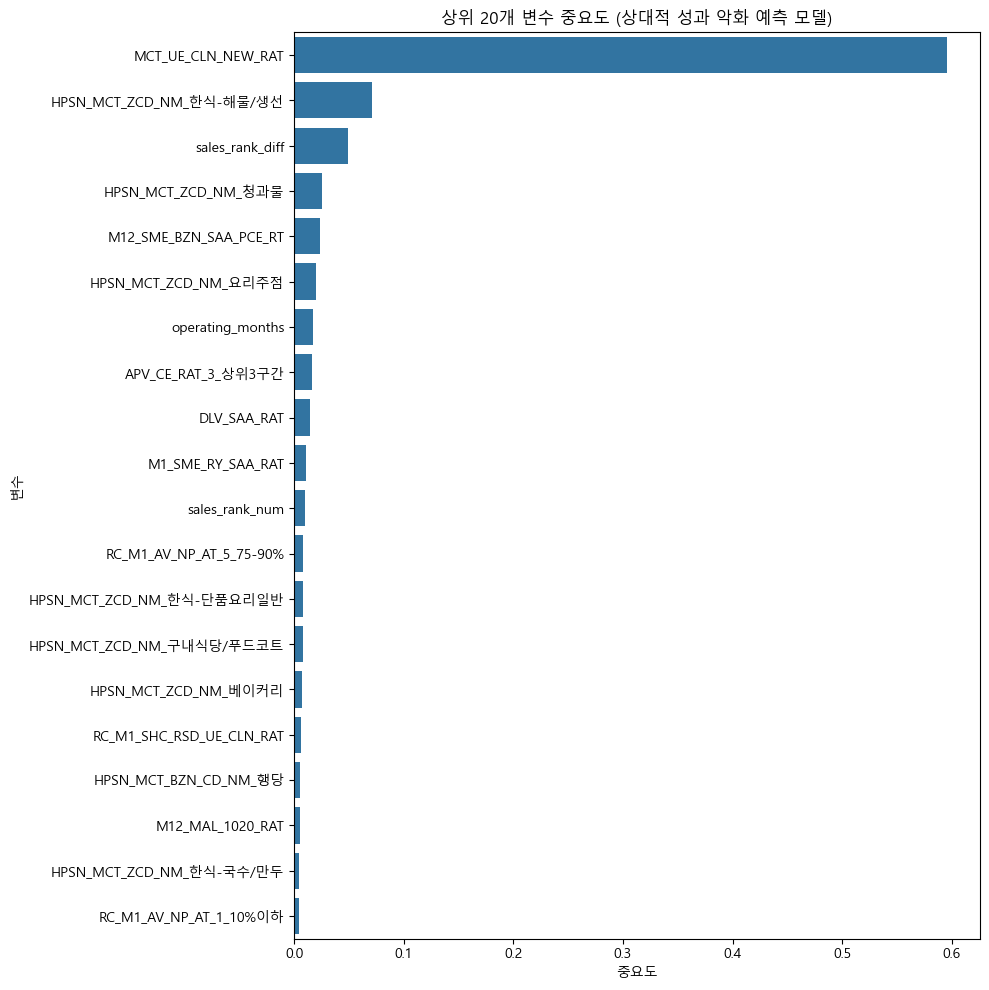

In [10]:
feature_importances = pd.Series(model_target3.feature_importances_, index=X.columns).sort_values(ascending=False)
    
plt.figure(figsize=(10, 10))
sns.barplot(x=feature_importances.head(20), y=feature_importances.head(20).index)
plt.title('상위 20개 변수 중요도 (상대적 성과 악화 예측 모델)')
plt.xlabel('중요도')
plt.ylabel('변수')
plt.tight_layout()
plt.show()

가게의 충성 고객층이 무너지고, 그 자리를 일회성 신규 고객이 채우기 시작하는 것은, 주변 경쟁 가게들에 비해 뒤처지기 시작하는 가장 강력한 전조증상이다???

Top N 도 한번 해볼게요요

In [11]:
# 1. 학습된 모델(model)에서 변수 중요도 정보 가져오기
feature_importances = pd.Series(model_target3.feature_importances_, index=X.columns)

# 2. 중요도 순으로 정렬하고 상위 15개 선택
N = 15
top_n_features = feature_importances.sort_values(ascending=False).head(N)

print(f"---  '매출 급락' 예측 핵심 변수 TOP {N} ---")
print(top_n_features)

# 3. 선택된 변수들의 이름을 리스트로 저장
#    이 리스트를 다음 모델 학습에 바로 사용할 수 있습니다.
list_of_top_n_features = top_n_features.index.tolist()
print("\n--- 다음 모델링에 사용할 변수 목록 ---")
print(list_of_top_n_features)

---  '매출 급락' 예측 핵심 변수 TOP 15 ---
MCT_UE_CLN_NEW_RAT           0.595935
HPSN_MCT_ZCD_NM_한식-해물/생선     0.070772
sales_rank_diff              0.049206
HPSN_MCT_ZCD_NM_청과물          0.025689
M12_SME_BZN_SAA_PCE_RT       0.023452
HPSN_MCT_ZCD_NM_요리주점         0.020056
operating_months             0.017294
APV_CE_RAT_3_상위3구간           0.016630
DLV_SAA_RAT                  0.014106
M1_SME_RY_SAA_RAT            0.010478
sales_rank_num               0.010078
RC_M1_AV_NP_AT_5_75-90%      0.008449
HPSN_MCT_ZCD_NM_한식-단품요리일반    0.008216
HPSN_MCT_ZCD_NM_구내식당/푸드코트    0.008148
HPSN_MCT_ZCD_NM_베이커리         0.006930
dtype: float32

--- 다음 모델링에 사용할 변수 목록 ---
['MCT_UE_CLN_NEW_RAT', 'HPSN_MCT_ZCD_NM_한식-해물/생선', 'sales_rank_diff', 'HPSN_MCT_ZCD_NM_청과물', 'M12_SME_BZN_SAA_PCE_RT', 'HPSN_MCT_ZCD_NM_요리주점', 'operating_months', 'APV_CE_RAT_3_상위3구간', 'DLV_SAA_RAT', 'M1_SME_RY_SAA_RAT', 'sales_rank_num', 'RC_M1_AV_NP_AT_5_75-90%', 'HPSN_MCT_ZCD_NM_한식-단품요리일반', 'HPSN_MCT_ZCD_NM_구내식당/푸드코트', 'HPSN_MCT_ZCD_NM_베이커리']


In [12]:
final_top_features = [col for col in list_of_top_n_features if col in X.columns]
X_simple = X[final_top_features]
print(f"\n✅ 핵심 변수 {len(X_simple.columns)}개를 선택하여 '단순 모델'을 준비했습니다.")


✅ 핵심 변수 15개를 선택하여 '단순 모델'을 준비했습니다.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42, stratify=y)

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
model_simple = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )

In [14]:
model_simple.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [15]:
y_pred = model_simple.predict(X_test)
print("\n--- 📊 '단순 모델' 성능 평가 (Top 1 변수 사용) ---")
print(classification_report(y_test, y_pred, target_names=['정상 (0)', '성과악화화 (1)']))


--- 📊 '단순 모델' 성능 평가 (Top 1 변수 사용) ---
              precision    recall  f1-score   support

      정상 (0)       1.00      1.00      1.00     17175
   성과악화화 (1)       0.78      0.90      0.83       143

    accuracy                           1.00     17318
   macro avg       0.89      0.95      0.92     17318
weighted avg       1.00      1.00      1.00     17318



처음께 더 나은 듯듯